Pretrained Models and Transfer Learning Project:  
Benjamin Kwon: 009241284

Python:  
v3.12.0

Dataset:  
CIFAR-10

Tech:  
Pytorch

Pretrained Model:  
EfficientNet-B0


In [38]:
# Import PyTorch and Detect GPU for hardware acceleration
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [39]:
# Extract weights and preprocessing from EfficientNet-B0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [40]:
# Load CIFAR-10 using EfficientNet-B0 preprocessing values with Data Augmentation
# Split the training set into train_subset and val_subset using indices

from torchvision import transforms
from torch.utils.data import Subset
import numpy as np

# Set transform values with respect to the pretrained model's weight and preprocessing values
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, interpolation=transforms.InterpolationMode.BICUBIC),# Data Augmentation: differing resize and crop
    transforms.RandomHorizontalFlip(),# Data Augmentation: Horizontal Flips
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load the CIFAR-10 with the transform composition
full_train_dataset_train_tf = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_train_dataset_eval_tf = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=eval_transform
)

num_train = len(full_train_dataset_train_tf)
indices = np.random.RandomState(seed=42).permutation(num_train)

train_size = int(0.9 * num_train)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(full_train_dataset_train_tf, train_indices)
val_subset = Subset(full_train_dataset_eval_tf, val_indices)

print("Train subset size:", len(train_subset))
print("Validation subset size:", len(val_subset))
print("Test dataset size:", len(test_dataset))

train_image, train_label = train_subset[0]
val_image, val_label = val_subset[0]
test_image, test_label = test_dataset[0]

print("Train image shape:", train_image.shape, "| label:", train_label)
print("Val image shape:", val_image.shape, "| label:", val_label)
print("Test image shape:", test_image.shape, "| label:", test_label)

Train subset size: 45000
Validation subset size: 5000
Test dataset size: 10000
Train image shape: torch.Size([3, 224, 224]) | label: 7
Val image shape: torch.Size([3, 224, 224]) | label: 3
Test image shape: torch.Size([3, 224, 224]) | label: 3


In [41]:
# DataLoader
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First 5 labels:", labels[:5])

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
First 5 labels: tensor([4, 5, 9, 6, 9])


In [42]:
# Load the Pretrained Model

model = efficientnet_b0(weights=weights)

print(model)
print(model.classifier)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [43]:
# Replace the classifier from 1000 to 10 class

import torch.nn as nn

model.classifier[1] = nn.Linear(in_features=1280, out_features=10)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [44]:
# Freeze the backbone: all parameters

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier head for initial training
for param in model.classifier.parameters():
    param.requires_grad = True

# Print what is trainable and what isn't
trainable_params = []
frozen_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)
    else:
        frozen_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print(" ", name)

print("\nNumber of trainable parameter tensors:", len(trainable_params))
print("Number of frozen parameter tensors:", len(frozen_params))

# Full List:
print('\nFull List: ')
for name, param in model.named_parameters():
    status = "trainable" if param.requires_grad else "frozen"
    print(f"{name:50s} {str(tuple(param.shape)):20s} {status}")

Trainable parameters:
  classifier.1.weight
  classifier.1.bias

Number of trainable parameter tensors: 2
Number of frozen parameter tensors: 211

Full List: 
features.0.0.weight                                (32, 3, 3, 3)        frozen
features.0.1.weight                                (32,)                frozen
features.0.1.bias                                  (32,)                frozen
features.1.0.block.0.0.weight                      (32, 1, 3, 3)        frozen
features.1.0.block.0.1.weight                      (32,)                frozen
features.1.0.block.0.1.bias                        (32,)                frozen
features.1.0.block.1.fc1.weight                    (8, 32, 1, 1)        frozen
features.1.0.block.1.fc1.bias                      (8,)                 frozen
features.1.0.block.1.fc2.weight                    (32, 8, 1, 1)        frozen
features.1.0.block.1.fc2.bias                      (32,)                frozen
features.1.0.block.2.0.weight                      

In [45]:
# Move the model to the device
model = model.to(device) # RTX 3080 TI

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), # Filter out frozen parameters; Train only the classifier head in this case
    lr = 1e-3 # Learning Rate
)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", num_trainable)
print("Total parameters:", num_total)

Trainable parameters: 12810
Total parameters: 4020358


In [46]:
# Training and Validation Loop
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Epoch training and evaluation
num_epochs = 5

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    epoch_duration = time.time() - epoch_start

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        f"| Time: {epoch_duration:.2f} sec"
    )

total_duration = time.time() - start_time
print(f"\nTotal training + validation time: {total_duration:.2f} sec")
print(f"Total time in minutes: {total_duration / 60:.2f} min")

Epoch [1/5] Train Loss: 1.3375 | Train Acc: 0.5514 | Val Loss: 0.7209 | Val Acc: 0.7730| Time: 43.64 sec
Epoch [2/5] Train Loss: 1.1668 | Train Acc: 0.5954 | Val Loss: 0.6538 | Val Acc: 0.7882| Time: 43.21 sec
Epoch [3/5] Train Loss: 1.1437 | Train Acc: 0.6041 | Val Loss: 0.6444 | Val Acc: 0.7868| Time: 43.59 sec
Epoch [4/5] Train Loss: 1.1326 | Train Acc: 0.6086 | Val Loss: 0.6233 | Val Acc: 0.7914| Time: 43.55 sec
Epoch [5/5] Train Loss: 1.1289 | Train Acc: 0.6085 | Val Loss: 0.6231 | Val Acc: 0.7874| Time: 43.44 sec

Total training + validation time: 217.43 sec
Total time in minutes: 3.62 min


# Analysis on the initial classifier-only transfer-learning phase

Over 5 epochs, the training loss steadily decreased and training accuracy increased. This shows that the classifier head successfully adapted to the CIFAR-10 task. Validation loss also decreased across epochs, and validation accuracy almost reached 80%, indicating that the pretrained backbone provided strong transferable image features even before fine-tuning deeper layers. Epoch 4 Had the highest validation accuracy of 79.14%

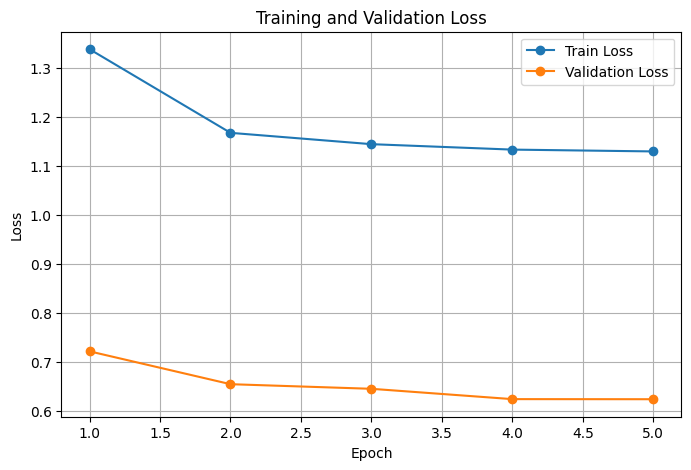

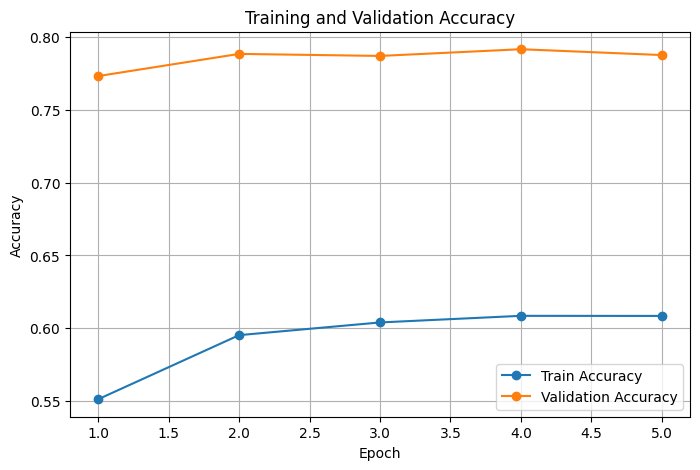

In [47]:
# Plot our results from the Initial Classifier-only Transfer-learning Phase

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
# Unfreeze the last 2 features for fine-tuning and set new learning reate of 1e-4

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for layer in model.features[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

trainable_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print(name)

Trainable parameters:
features.7.0.block.0.0.weight
features.7.0.block.0.1.weight
features.7.0.block.0.1.bias
features.7.0.block.1.0.weight
features.7.0.block.1.1.weight
features.7.0.block.1.1.bias
features.7.0.block.2.fc1.weight
features.7.0.block.2.fc1.bias
features.7.0.block.2.fc2.weight
features.7.0.block.2.fc2.bias
features.7.0.block.3.0.weight
features.7.0.block.3.1.weight
features.7.0.block.3.1.bias
features.8.0.weight
features.8.1.weight
features.8.1.bias
classifier.1.weight
classifier.1.bias


In [49]:
# Fine-tune 1: Train the last two features and the classifier head

# Epoch training and evaluation
num_epochs = 5

ft1_train_losses = []
ft1_train_accuracies = []
ft1_val_losses = []
ft1_val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    epoch_duration = time.time() - epoch_start

    ft1_train_losses.append(train_loss)
    ft1_train_accuracies.append(train_acc)
    ft1_val_losses.append(val_loss)
    ft1_val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        f"| Time: {epoch_duration:.2f} sec"
    )

total_duration = time.time() - start_time
print(f"\nTotal training + validation time: {total_duration:.2f} sec")
print(f"Total time in minutes: {total_duration / 60:.2f} min")

Epoch [1/5] Train Loss: 1.0100 | Train Acc: 0.6500 | Val Loss: 0.4675 | Val Acc: 0.8378| Time: 45.44 sec
Epoch [2/5] Train Loss: 0.9092 | Train Acc: 0.6837 | Val Loss: 0.4103 | Val Acc: 0.8566| Time: 45.17 sec
Epoch [3/5] Train Loss: 0.8536 | Train Acc: 0.7013 | Val Loss: 0.3846 | Val Acc: 0.8638| Time: 45.56 sec
Epoch [4/5] Train Loss: 0.8189 | Train Acc: 0.7139 | Val Loss: 0.3706 | Val Acc: 0.8694| Time: 45.40 sec
Epoch [5/5] Train Loss: 0.7853 | Train Acc: 0.7236 | Val Loss: 0.3542 | Val Acc: 0.8724| Time: 45.37 sec

Total training + validation time: 226.94 sec
Total time in minutes: 3.78 min


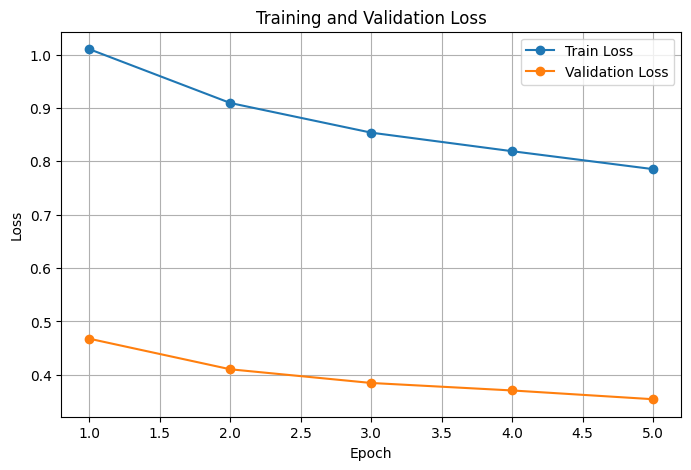

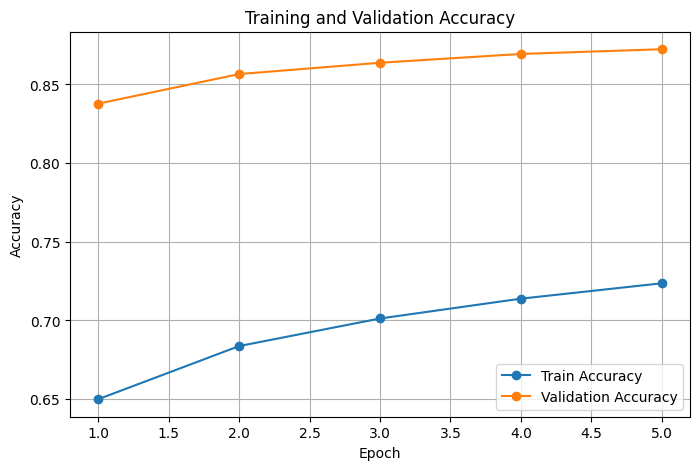

In [50]:
# Plot our results for Fine-Tune 1: Last 2 features and a classifier head

epochs = range(1, len(ft1_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft1_train_losses, marker='o', label='Train Loss')
plt.plot(epochs, ft1_val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft1_train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, ft1_val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Analysis on Fine-Tune 1: Train Last 2 Features and the Classifier Head
After the initial classifier-only transfer-learning phase, the last two feature stages of the EfficientNet-B0 backbone were unfrozen and fine-tuned using a smaller learning rate of 1e-4. This significantly improved performance where the validation accuracy increased from 79.14% to 87.24% after fine-tuning, while validation loss decreased from 0.4675 to 0.3542 over 5 epochs. These results indicate that the classifier head and the later backbone features adjusted together to better fit the CIFAR-10 task.

In [51]:
# Test Evaluation

def evaluate_on_test(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc

test_loss, test_acc = evaluate_on_test(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy (%): {test_acc * 100:.2f}%")

Test Loss: 0.3587
Test Accuracy: 0.8775
Test Accuracy (%): 87.75%


# Test Evaluation Report
The fine-tuned transfer-learning EfficientNet-B0 model achieved a test accuracy of 87.75% with a test loss of 0.3587 on CIFAR-10. This result is consistent with the validation performance observed during fine-tuning, suggesting that the model generalized well to unseen test data.
This was accomplished by training the classifier head and the last two features: feature 7 and 8.